# Explainability: Grad-CAM, LIME and Their Agreement.

Generate post-hoc attributions for the eight retrained checkpoints and quantify
how far the two methods agree on the same regions.

The Agreement Index reported in the submitted version was invalid. It was
computed by reading back rendered PNG figures and thresholding them at a fixed
quantile. Because a rendered LIME figure is mostly black background, more than
seventy per cent of its pixels were exactly zero, so the seventieth percentile
was itself zero and the mask `image >= 0` selected every pixel. The metric
therefore reduced to a function of the threshold parameter: pairs in which both
figures were mostly black returned exactly 1.0, and the remainder returned
1 minus the quantile, that is 0.30. The mean of one such degenerate value and
two threshold readouts is 0.5333 with a sample standard deviation of 0.4041,
which reproduces the reported band of 0.534 to 0.537 plus or minus 0.40 exactly.
No quantity in that section depended on any model.

This notebook computes the index from the raw arrays instead, never from a
rendered figure, and tests whether the result is stable under the choice of
threshold.

#### Rationale:
- Derive both masks from the underlying data: the Grad-CAM activation array and
  the LIME superpixel weights, neither of which passes through an image file.
- Evaluate on a sample of images per class rather than a single representative
  one, so that the reported spread reflects variation between cases.
- Test sensitivity to the Grad-CAM threshold, since intersection over union
  between a fixed-area and a variable-area mask can be dominated by that choice.
- Report mask coverage alongside the index, because the attainable maximum is
  bounded by the ratio of the two mask areas.

## 1. Imports and Path Setup.

Configure directories and device, and make the project modules under `src/`
importable. The structure follows notebooks 01 to 04.

#### Rationale:
- Keep path handling identical across the pipeline.
- Separate the output directory for regenerated figures from the archived ones
  produced by the superseded checkpoints.
- Detect the compute device automatically.
- Fail early if a required directory is absent.

In [1]:
import sys, json, math, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.nn import functional as F
from torchvision import models
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_DIR      = PROJECT_ROOT / "data"
EXPERIMENTS   = PROJECT_ROOT / "experiments"
CHECKPOINTS   = EXPERIMENTS / "checkpoints"
POOLS_DIR     = EXPERIMENTS / "pools"
SPLITS_DIR    = EXPERIMENTS / "pools_clean"
REPORTS_DIR   = PROJECT_ROOT / "reports"
FIG_DIR       = REPORTS_DIR / "figures" / "explainability"
TABLE_DIR     = REPORTS_DIR / "tables"

for d in (FIG_DIR, TABLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

warnings.filterwarnings("ignore", category=FutureWarning)

print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {DEVICE.upper()}")

Project root: /lab/px/AnichLabs/cxr-cnn-k8s-benchmark
Device: CUDA


## 2. Configuration.

Load the preprocessing constants and set the parameters of the analysis.

`N_PER_CLASS` controls how many test images are analysed per class for each
model and regime. The submitted version used one image per class, so each
model-regime pair rested on three values and the quoted standard deviation was
the spread of those three. Twenty per class gives sixty per pair.

#### Rationale:
- Read the class mapping and normalisation statistics from the same
  configuration file used in training, so that the attributions correspond to
  the inputs the models actually saw.
- Set the sample size explicitly, since it determines whether the reported
  spread means anything.
- Expose the Grad-CAM threshold as a list, so that sensitivity can be tested
  rather than assumed.
- Fix the sampling seed so that the selected images are reproducible.

In [2]:
cfg_path = POOLS_DIR / "preprocessing_config.json"
if not cfg_path.exists():
    raise FileNotFoundError("Missing preprocessing_config.json (run 01_data_eda first).")
cfg = json.loads(cfg_path.read_text())

IMG_SIZE       = int(cfg["img_size"])
CLASS_TO_INDEX = {k: int(v) for k, v in cfg["class_to_index"].items()}
INDEX_TO_CLASS = {v: k for k, v in CLASS_TO_INDEX.items()}
IMAGENET_MEAN, IMAGENET_STD = cfg["imagenet_mean"], cfg["imagenet_std"]
CXR_MEAN, CXR_STD           = cfg["cxr_mean"], cfg["cxr_std"]

# --- Analysis parameters ---
N_PER_CLASS   = 20          # Test images per class, per model-regime pair.
LIME_SAMPLES  = 1000        # Perturbations per LIME explanation.
LIME_BATCH    = 64          # Perturbations per forward pass. LIME defaults to 10,
                            # which underuses the GPU; larger batches are much faster.
GRADCAM_TOPK  = [0.10, 0.20, 0.30]   # Fractions retained; the middle is primary.
PRIMARY_TOPK  = 0.20
SEED          = 42

MODEL_NAMES = ["mobilenet_v2", "efficientnet_b0", "resnet50", "victorio"]
REGIMES     = ["imagenet", "cxr"]

# Set PILOT = True to run a single pair first and check timing before committing
# to the full sweep. LIME is the bottleneck at roughly a few seconds per image.
PILOT = False

print(f"Image size    : {IMG_SIZE}")
print(f"Classes       : {CLASS_TO_INDEX}")
print(f"Per class     : {N_PER_CLASS} images  ({N_PER_CLASS * len(CLASS_TO_INDEX)} per pair)")
print(f"LIME samples  : {LIME_SAMPLES} (batch {LIME_BATCH})")
print(f"Grad-CAM top-k: {GRADCAM_TOPK} (primary {PRIMARY_TOPK})")
print(f"Mode          : {'PILOT (one pair)' if PILOT else 'FULL (eight pairs)'}")

Image size    : 256
Classes       : {'Pneumonia': 0, 'TB': 1, 'Normal': 2}
Per class     : 20 images  (60 per pair)
LIME samples  : 1000 (batch 64)
Grad-CAM top-k: [0.1, 0.2, 0.3] (primary 0.2)
Mode          : FULL (eight pairs)


## 3. Test Images.

Sample images from the clean test split. Only images the model classifies
correctly are used, since an attribution map for a misclassification explains
the wrong prediction and would confuse the agreement measurement.

#### Rationale:
- Read from `experiments/pools_clean/`, never from the superseded pool.
- Assert the split size, consistent with the other notebooks.
- Draw a fixed random sample per class with a set seed, so the selection is
  reproducible and not simply the first rows of the file.
- Resolve absolute paths through the same two-valued source key used by the
  dataset class.

In [3]:
test_df = pd.read_csv(SPLITS_DIR / "test_split.csv")

EXPECTED_TEST = 480
if len(test_df) != EXPECTED_TEST:
    raise ValueError(
        f"Unexpected test split size: {len(test_df)}. Expected {EXPECTED_TEST}. "
        "Check that experiments/pools_clean/ holds the rebuilt splits."
    )

CHEXPERT_PATH = DATA_DIR / "chexpert"
TBX11K_PATH   = DATA_DIR / "tbx11k"

def resolve_path(row) -> Path:
    """Absolute path, matching CXRThreeClassDataset.__getitem__."""
    if row["Source"] == "chexpert":
        return CHEXPERT_PATH / row["rel_path"]
    return TBX11K_PATH / "imgs" / row["rel_path"]

test_df["resolved"] = test_df.apply(resolve_path, axis=1)
missing = [p for p in test_df["resolved"] if not Path(p).exists()]
if missing:
    raise FileNotFoundError(f"{len(missing)} test images could not be resolved, "
                            f"first: {missing[0]}")

# Fixed random sample per class.
sample_df = (
    test_df.groupby("Class", group_keys=False)
           .apply(lambda g: g.sample(n=min(N_PER_CLASS, len(g)), random_state=SEED))
           .reset_index(drop=True)
)

print(f"Sampled {len(sample_df)} images:")
print(sample_df["Class"].value_counts().to_string())

Sampled 60 images:
Class
Normal       20
Pneumonia    20
TB           20


## 4. Model Builder.

Rebuild each architecture as defined in `03_model_training.ipynb` and identify
the convolutional layer from which Grad-CAM is taken.

#### Rationale:
- Match the training-time structure so that checkpoints load without mismatch.
- Return the target layer alongside the model, so the Grad-CAM hook attaches to
  a layer chosen deliberately rather than by position.
- Take the last activated convolutional feature map in every case, which is the
  conventional choice and keeps the comparison across architectures consistent.
- Instantiate without pretrained weights, since the checkpoint supplies all parameters.

In [4]:
def build_model(model_name: str, num_classes: int):
    """
    Return (model, target_layer) where target_layer is the last activated
    convolutional feature map used as the Grad-CAM source.
    """
    if model_name == "mobilenet_v2":
        m = models.mobilenet_v2(weights=None)
        m.classifier[1] = nn.Linear(m.last_channel, num_classes)
        target = m.features[-1]
    elif model_name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=None)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
        target = m.features[-1]
    elif model_name == "resnet50":
        m = models.resnet50(weights=None)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
        target = m.layer4[-1]
    elif model_name == "victorio":
        m = nn.Sequential(
            nn.Conv2d(3, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4, 4)), nn.Flatten(),
            nn.Linear(32 * 4 * 4, num_classes),
        )
        target = m[4]           # ReLU after the second convolution.
    else:
        raise ValueError(f"Unknown model: {model_name}")
    return m, target


def load_checkpoint(model_name: str, regime: str):
    """Build the architecture and load its trained weights."""
    ckpt = CHECKPOINTS / f"{model_name}_{regime}_best.pt"
    if not ckpt.exists():
        raise FileNotFoundError(f"Missing checkpoint: {ckpt}")
    model, target = build_model(model_name, len(CLASS_TO_INDEX))
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    return model.to(DEVICE).eval(), target

## 5. Grad-CAM.

Gradient-weighted class activation mapping. The implementation returns the
normalised activation array directly; it is never written to or read from an
image file.

#### Rationale:
- Return the raw array, which is the quantity the agreement measurement needs.
- Use `register_full_backward_hook`, since `register_backward_hook` is deprecated
  and does not fire reliably for all module types.
- Remove the hooks after use, so that repeated instantiation across eight
  checkpoints does not accumulate handles on the same modules.
- Upsample to the input resolution so that the map is directly comparable with
  the LIME segmentation.

In [5]:
class GradCAM:
    """Grad-CAM returning the raw normalised activation array."""

    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.activations = None
        self.gradients = None
        self._handles = [
            target_layer.register_forward_hook(self._fwd),
            target_layer.register_full_backward_hook(self._bwd),
        ]

    def _fwd(self, module, inp, out):
        self.activations = out.detach()

    def _bwd(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def remove(self):
        for h in self._handles:
            h.remove()
        self._handles = []

    def generate(self, input_tensor: torch.Tensor, class_idx: int = None) -> np.ndarray:
        """Return a HxW array in [0, 1] for the given class."""
        self.model.zero_grad()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = int(output.argmax(dim=1).item())
        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=input_tensor.shape[2:],
                            mode="bilinear", align_corners=False)
        cam = cam.squeeze().detach().cpu().numpy()
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

## 6. Masks and Agreement.

Convert each attribution into a binary mask and measure their overlap.

The Grad-CAM mask retains the highest activating fraction of pixels. The LIME
mask is the union of superpixels whose fitted weight is positive, taken from the
explanation object rather than from a drawn figure, so its area is determined by
the explanation rather than by a threshold.

The two masks are therefore not equal in area, and the attainable intersection
over union is bounded by the ratio of the smaller to the larger. Both coverages
are recorded so that the bound is visible.

#### Rationale:
- Derive the Grad-CAM mask from the activation array by rank, which is well
  defined even when the array has ties.
- Derive the LIME mask from `local_exp`, the fitted superpixel weights, which is
  what LIME actually reports as supporting evidence.
- Record the area of each mask, since intersection over union between masks of
  unequal size cannot reach one.
- Compute the index at several thresholds, so that dependence on the threshold
  can be measured rather than assumed absent.

In [6]:
def gradcam_mask(cam: np.ndarray, top_fraction: float) -> np.ndarray:
    """
    Boolean mask retaining the highest activating `top_fraction` of pixels.

    Selection is by rank rather than by value, so the mask has the intended area
    even when the array contains ties. The previous implementation thresholded a
    rendered figure at a quantile, which on a mostly-black image selected every
    pixel.
    """
    k = max(1, int(round(top_fraction * cam.size)))
    flat = cam.ravel()
    idx = np.argpartition(flat, -k)[-k:]
    mask = np.zeros(cam.size, dtype=bool)
    mask[idx] = True
    return mask.reshape(cam.shape)


def lime_mask(explanation, label: int) -> np.ndarray:
    """
    Boolean mask of superpixels with positive fitted weight for `label`.

    Read from the explanation object. Its area is set by the explanation, not by
    a threshold, so it varies between images.
    """
    positive = [seg for seg, weight in explanation.local_exp[label] if weight > 0]
    return np.isin(explanation.segments, positive)


def iou(a: np.ndarray, b: np.ndarray) -> float:
    """Intersection over union of two boolean masks."""
    union = np.logical_or(a, b).sum()
    return float(np.logical_and(a, b).sum() / union) if union else float("nan")

## 7. Compute Attributions and Agreement.

For every model, regime and sampled image: run Grad-CAM, run LIME, and measure
the overlap at each threshold. Both attributions are computed in the same pass
and compared as arrays, so nothing is written to disk in between.

Every image is recorded, together with whether the model classified it
correctly. The reported index is taken over correctly classified cases, since an
attribution for a wrong prediction explains the wrong class; retaining the
remainder allows that restriction to be checked rather than assumed harmless.

Both attributions target the true class throughout, so that correct and
incorrect cases are explained with respect to the same quantity and remain
comparable.

#### Rationale:
- Compute Grad-CAM and LIME together, so the comparison is between the two
  attributions of the same prediction on the same input.
- Record correctness rather than discarding it, so the effect of restricting to
  correct cases becomes measurable.
- Normalise inputs per regime, matching the statistics each checkpoint was trained under.
- Record every image individually, so the distribution can be inspected rather
  than only its mean.

In [7]:
from lime import lime_image
import lime.lime_image
from src.transforms import build_shared_transforms
import time

# Suppress LIME's per-image progress bars. It binds the symbol at import time
# via "from tqdm.auto import tqdm", so the name must be replaced on the module
# itself; patching tqdm.tqdm afterwards does not reach it. One bar per image
# across 480 explanations is unreadable and obscures the printed results.
lime.lime_image.tqdm = lambda iterable, *args, **kwargs: iterable

explainer = lime_image.LimeImageExplainer(random_state=SEED)

pairs = [(m, r) for m in MODEL_NAMES for r in REGIMES]
if PILOT:
    pairs = pairs[:1]
    print(f"PILOT: {pairs[0][0]} / {pairs[0][1]} only.\n")

total_images = len(pairs) * len(sample_df)
print(f"{len(pairs)} pairs x {len(sample_df)} images = {total_images} explanations\n")

records = []
run_start = time.time()
done_overall = 0

for pair_no, (model_name, regime) in enumerate(pairs, start=1):
    model, target_layer = load_checkpoint(model_name, regime)
    mean, std = ((IMAGENET_MEAN, IMAGENET_STD) if regime == "imagenet"
                 else (CXR_MEAN, CXR_STD))
    _, eval_tf = build_shared_transforms(img_size=IMG_SIZE, mean=mean, std=std)

    mean_t = torch.tensor(mean).view(1, 3, 1, 1).to(DEVICE)
    std_t  = torch.tensor(std).view(1, 3, 1, 1).to(DEVICE)

    def batch_predict(batch: np.ndarray) -> np.ndarray:
        """LIME supplies unnormalised RGB in [0,1]; normalise here."""
        with torch.no_grad():
            t = torch.from_numpy(np.stack(batch)).permute(0, 3, 1, 2).float().to(DEVICE)
            t = (t - mean_t) / std_t
            return torch.softmax(model(t), dim=1).cpu().numpy()

    cam_engine = GradCAM(model, target_layer)
    n_correct = n_wrong = 0
    pair_start = time.time()
    label = f"{model_name}/{regime}"

    for img_no, (_, row) in enumerate(sample_df.iterrows(), start=1):
        true_idx = CLASS_TO_INDEX[row["Class"]]

        pil = Image.open(row["resolved"]).convert("RGB")
        tensor = eval_tf(pil).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            pred_idx = int(model(tensor).argmax(dim=1).item())
        is_correct = (pred_idx == true_idx)
        n_correct += int(is_correct)
        n_wrong   += int(not is_correct)

        # Grad-CAM on the raw array.
        cam = cam_engine.generate(tensor, class_idx=true_idx)

        # LIME on the same image, unnormalised, as LIME perturbs raw pixels.
        rgb = np.asarray(pil.resize((IMG_SIZE, IMG_SIZE)), dtype=np.float64) / 255.0
        explanation = explainer.explain_instance(
            rgb, batch_predict, labels=(true_idx,), top_labels=None,
            hide_color=0, num_samples=LIME_SAMPLES,
            batch_size=LIME_BATCH, random_seed=SEED,
        )
        l_mask = lime_mask(explanation, true_idx)

        for topk in GRADCAM_TOPK:
            g_mask = gradcam_mask(cam, topk)
            records.append({
                "model": model_name,
                "regime": regime,
                "class": row["Class"],
                "rel_path": row["rel_path"],
                "correct": bool(is_correct),
                "predicted": INDEX_TO_CLASS[pred_idx],
                "topk": topk,
                "iou": iou(g_mask, l_mask),
                "gradcam_coverage": float(g_mask.mean()),
                "lime_coverage": float(l_mask.mean()),
            })

        # In-place progress. LIME takes seconds per image, so a silent loop of
        # 480 explanations gives no indication of whether it is still running.
        done_overall += 1
        pair_elapsed = time.time() - pair_start
        per_image    = pair_elapsed / img_no
        overall_eta  = per_image * (total_images - done_overall)
        print(f"\r  [{pair_no}/{len(pairs)}] {label:26s} "
              f"{img_no:3d}/{len(sample_df)} ({img_no / len(sample_df):5.1%})  "
              f"{per_image:4.1f}s/img  "
              f"overall {done_overall:3d}/{total_images} "
              f"eta {overall_eta / 60:5.1f} min",
              end="", flush=True)

    cam_engine.remove()
    print(f"\r  [{pair_no}/{len(pairs)}] {label:26s} "
          f"correct {n_correct:3d}  incorrect {n_wrong:3d}  "
          f"({time.time() - pair_start:5.1f}s)"
          + " " * 30)

agreement_df = pd.DataFrame(records)
out_csv = TABLE_DIR / "agreement_index_raw.csv"
agreement_df.to_csv(out_csv, index=False)
print()
print(f"Completed in {(time.time() - run_start) / 60:.1f} minutes.")
print(f"{len(agreement_df):,} rows written to {out_csv.relative_to(PROJECT_ROOT)}")

8 pairs x 60 images = 480 explanations

  [1/8] mobilenet_v2/imagenet      correct  57  incorrect   3  (175.2s)                              
  [2/8] mobilenet_v2/cxr           correct  53  incorrect   7  (168.6s)                              
  [3/8] efficientnet_b0/imagenet   correct  59  incorrect   1  (175.2s)                              
  [4/8] efficientnet_b0/cxr        correct  55  incorrect   5  (171.3s)                              
  [5/8] resnet50/imagenet          correct  60  incorrect   0  (197.4s)                              
  [6/8] resnet50/cxr               correct  56  incorrect   4  (197.4s)                              
  [7/8] victorio/imagenet          correct  53  incorrect   7  (156.3s)                              
  [8/8] victorio/cxr               correct  52  incorrect   8  (156.2s)                              

Completed in 23.3 minutes.
1,440 rows written to reports/tables/agreement_index_raw.csv


## 8. Threshold Sensitivity.

Test whether the index depends on the choice of Grad-CAM threshold.

This is the check whose absence allowed the original error to stand. If the
values move together as the threshold changes but the ordering across models is
preserved, the index is measuring a property of the attributions. If the
ordering itself changes, the index is dominated by the threshold and should not
be reported as a single number.

#### Rationale:
- Compare the same pairs at three thresholds, so that dependence is measurable.
- Report the rank correlation between thresholds, which is the quantity that
  determines whether a single reported value is meaningful.
- Show mask coverage, since intersection over union between unequal masks is
  bounded above by their area ratio.
- Make the outcome explicit rather than leaving it to interpretation.

In [8]:
from scipy.stats import spearmanr

correct_only = agreement_df[agreement_df["correct"]]
pair_means = (correct_only
              .groupby(["model", "regime", "topk"])["iou"]
              .mean().reset_index())

pivot = pair_means.pivot_table(index=["model", "regime"],
                               columns="topk", values="iou")
print("Mean Agreement Index by Grad-CAM threshold:")
print(pivot.round(4).to_string())

print()
print("Rank correlation between thresholds (Spearman):")
cols = list(pivot.columns)
stable = True
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        rho, p = spearmanr(pivot[cols[i]], pivot[cols[j]])
        print(f"  top-{cols[i]:.0%} vs top-{cols[j]:.0%}: rho={rho:+.3f}  p={p:.4f}")
        if rho < 0.7:
            stable = False

print()
print("Mask coverage (mean fraction of image):")
cov = (correct_only[correct_only["topk"] == PRIMARY_TOPK]
       .groupby(["model", "regime"])[["gradcam_coverage", "lime_coverage"]]
       .mean().round(3))
print(cov.to_string())
print()
print(f"At top-{PRIMARY_TOPK:.0%}, the Grad-CAM mask covers {PRIMARY_TOPK:.0%} by construction. "
      "Where the LIME mask is larger, the attainable maximum for the index is the "
      "ratio of the two areas, not one.")

print()
if stable:
    print("RESULT: the ordering across model-regime pairs is preserved across "
          "thresholds. The index reflects a property of the attributions and a "
          "single threshold may be reported, with the sensitivity table as support.")
else:
    print("RESULT: the ordering changes with the threshold. The index is "
          "threshold-dominated and should not be reported as a single value. "
          "Replace Section 5.2 with a qualitative treatment of the heatmaps.")

Mean Agreement Index by Grad-CAM threshold:
topk                         0.1     0.2     0.3
model           regime                          
efficientnet_b0 cxr       0.0971  0.1828  0.2569
                imagenet  0.1252  0.2427  0.3514
mobilenet_v2    cxr       0.0952  0.1778  0.2520
                imagenet  0.1105  0.2158  0.3157
resnet50        cxr       0.0661  0.1321  0.1982
                imagenet  0.1002  0.1993  0.2958
victorio        cxr       0.0801  0.1434  0.2059
                imagenet  0.0773  0.1430  0.2068

Rank correlation between thresholds (Spearman):
  top-10% vs top-20%: rho=+1.000  p=0.0000
  top-10% vs top-30%: rho=+0.976  p=0.0000
  top-20% vs top-30%: rho=+0.976  p=0.0000

Mask coverage (mean fraction of image):
                          gradcam_coverage  lime_coverage
model           regime                                   
efficientnet_b0 cxr                    0.2          0.696
                imagenet               0.2          0.783
mobilenet_v2   

## 9. Summary and Figure.

Summarise the index at the primary threshold, with confidence intervals from the
distribution across images.

The reported values use correctly classified cases only. Sample sizes therefore
differ between models: the compact architecture classifies fewer of the sampled
images correctly, so fewer of its cases contribute and its interval is
correspondingly wider. Equalising the counts would mean restricting every model
to the images the weakest one classifies correctly, which would confine the
analysis to the easiest cases; reporting the counts is preferable to selecting
on difficulty.

#### Rationale:
- Report the mean with an interval derived from the spread across images, which
  is now a sample of twenty per class rather than one.
- State the sample size for every value, so that unequal counts are visible
  rather than concealed.
- Compare correct against incorrect predictions, so the effect of the
  restriction is measured rather than assumed.
- Break the result down by class, since the size and coherence of the
  discriminative region differs between a diffuse opacity and a focal lesion.

Agreement Index at top-20%, correctly classified cases (mean +/- 95% CI):
  efficientnet_b0  cxr       0.1828 +/- 0.0114  (n=55)
  efficientnet_b0  imagenet  0.2427 +/- 0.0109  (n=59)
  mobilenet_v2     cxr       0.1778 +/- 0.0165  (n=53)
  mobilenet_v2     imagenet  0.2158 +/- 0.0109  (n=57)
  resnet50         cxr       0.1321 +/- 0.0250  (n=56)
  resnet50         imagenet  0.1993 +/- 0.0075  (n=60)
  victorio         cxr       0.1434 +/- 0.0128  (n=52)
  victorio         imagenet  0.1430 +/- 0.0139  (n=53)

Sample sizes differ because the models classify different numbers of the sampled images correctly. This is reported rather than equalised: restricting every model to the cases the weakest one gets right would confine the whole analysis to the easiest images.

Correct versus incorrect predictions:
          model   regime  correct  count   mean
efficientnet_b0      cxr    False      5 0.1964
efficientnet_b0      cxr     True     55 0.1828
efficientnet_b0 imagenet    False      1 0.

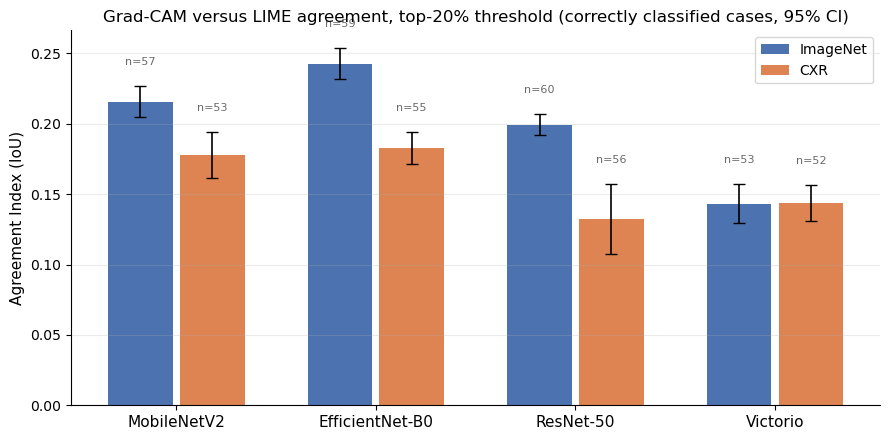


Saved: reports/figures/explainability/agreement_index_summary.png


In [9]:
# The reported index uses correctly classified cases only.
primary_all = agreement_df[agreement_df["topk"] == PRIMARY_TOPK]
primary     = primary_all[primary_all["correct"]]

summary = (primary.groupby(["model", "regime"])["iou"]
           .agg(["count", "mean", "std"])
           .reset_index())
summary["sem"]  = summary["std"] / np.sqrt(summary["count"])
summary["ci95"] = 1.96 * summary["sem"]

print(f"Agreement Index at top-{PRIMARY_TOPK:.0%}, correctly classified cases "
      f"(mean +/- 95% CI):")
for _, r in summary.iterrows():
    print(f"  {r['model']:16s} {r['regime']:9s} "
          f"{r['mean']:.4f} +/- {r['ci95']:.4f}  (n={int(r['count'])})")

print()
print("Sample sizes differ because the models classify different numbers of the "
      "sampled images correctly. This is reported rather than equalised: "
      "restricting every model to the cases the weakest one gets right would "
      "confine the whole analysis to the easiest images.")

# Check that restricting to correct cases does not change the picture.
check = (primary_all.groupby(["model", "regime", "correct"])["iou"]
         .agg(["count", "mean"]).round(4).reset_index())
print()
print("Correct versus incorrect predictions:")
print(check.to_string(index=False))

wrong = check[~check["correct"]]
if wrong["count"].sum() < 10:
    print()
    print("Too few incorrect cases to compare meaningfully.")
else:
    merged = check.pivot_table(index=["model", "regime"], columns="correct",
                               values="mean")
    if merged.shape[1] == 2:
        delta = (merged[True] - merged[False]).abs().mean()
        print()
        print(f"Mean absolute difference between correct and incorrect cases: {delta:.4f}")
        if delta < 0.05:
            print("The restriction to correct cases does not materially change the index.")
        else:
            print("The index differs between correct and incorrect predictions; "
                  "state the restriction explicitly in the paper.")

by_class = (primary.groupby(["class"])["iou"]
            .agg(["count", "mean", "std"]).round(4))
print()
print("By class, correctly classified cases pooled across models:")
print(by_class.to_string())

summary.to_csv(TABLE_DIR / "agreement_index_summary.csv", index=False)

# Figure, drawn from the table above.
fig, ax = plt.subplots(figsize=(9, 4.5))
DISPLAY = {"mobilenet_v2": "MobileNetV2", "efficientnet_b0": "EfficientNet-B0",
           "resnet50": "ResNet-50", "victorio": "Victorio"}
width = 0.36
for i, arch in enumerate(MODEL_NAMES):
    for j, regime in enumerate(REGIMES):
        sel = summary[(summary["model"] == arch) & (summary["regime"] == regime)]
        if sel.empty:
            continue
        r = sel.iloc[0]
        x = i + (j - 0.5) * width
        ax.bar(x, r["mean"], width * 0.9,
               color="#4C72B0" if regime == "imagenet" else "#DD8452",
               label=("ImageNet" if regime == "imagenet" else "CXR") if i == 0 else None)
        ax.errorbar(x, r["mean"], yerr=r["ci95"], fmt="none",
                    ecolor="black", capsize=4, lw=1.2)
        ax.text(x, r["mean"] + r["ci95"] + 0.015, f'n={int(r["count"])}',
                ha="center", fontsize=8, color="dimgray")

ax.set_xticks(range(len(MODEL_NAMES)))
ax.set_xticklabels([DISPLAY[m] for m in MODEL_NAMES], fontsize=11)
ax.set_ylabel("Agreement Index (IoU)", fontsize=11)
ax.set_title(f"Grad-CAM versus LIME agreement, top-{PRIMARY_TOPK:.0%} threshold "
             f"(correctly classified cases, 95% CI)", fontsize=12)
ax.legend(fontsize=10, frameon=True)
ax.grid(axis="y", alpha=0.25)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

plt.tight_layout()
out = FIG_DIR / "agreement_index_summary.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print()
print("Saved:", out.relative_to(PROJECT_ROOT))

## 10. Qualitative Figures.

Regenerate the Grad-CAM and LIME panels for one representative case per class,
for inclusion in the appendix.

The submitted version described the custom architecture's Grad-CAM as covering
the lung area in a broader, less sharply defined pattern. Reviewer 5 observed
that this contradicts the figure. The claim is not restated here; whatever the
regenerated panels show should be described from them.

#### Rationale:
- Produce the panels from the retrained checkpoints, since the archived figures
  were generated from the superseded models.
- Show Grad-CAM and LIME for the same case side by side, so the agreement values
  can be read against the images.
- Keep the qualitative figure separate from the quantitative measurement, which
  no longer depends on it.
- Describe what the panels show rather than restating the earlier claim.

Representative cases: ['health/h3086.png', 'train/patient40094/study1/view1_frontal.jpg', 'tb/tb1139.png']


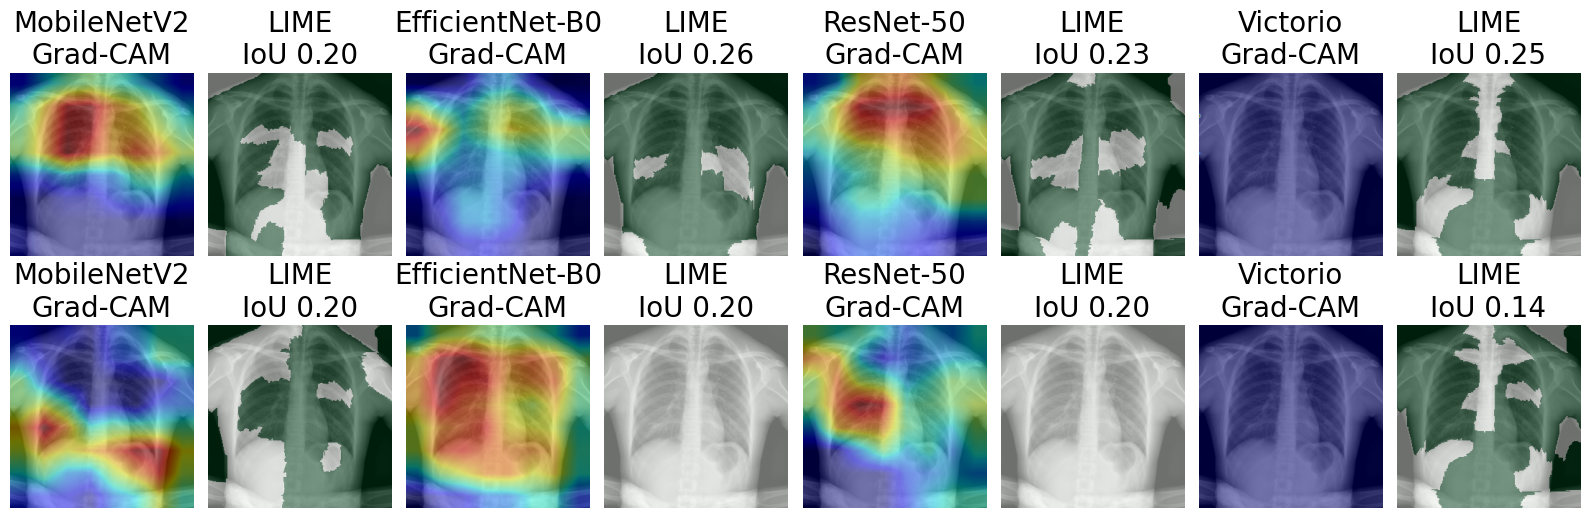

Saved: reports/figures/explainability/attributions_normal.png


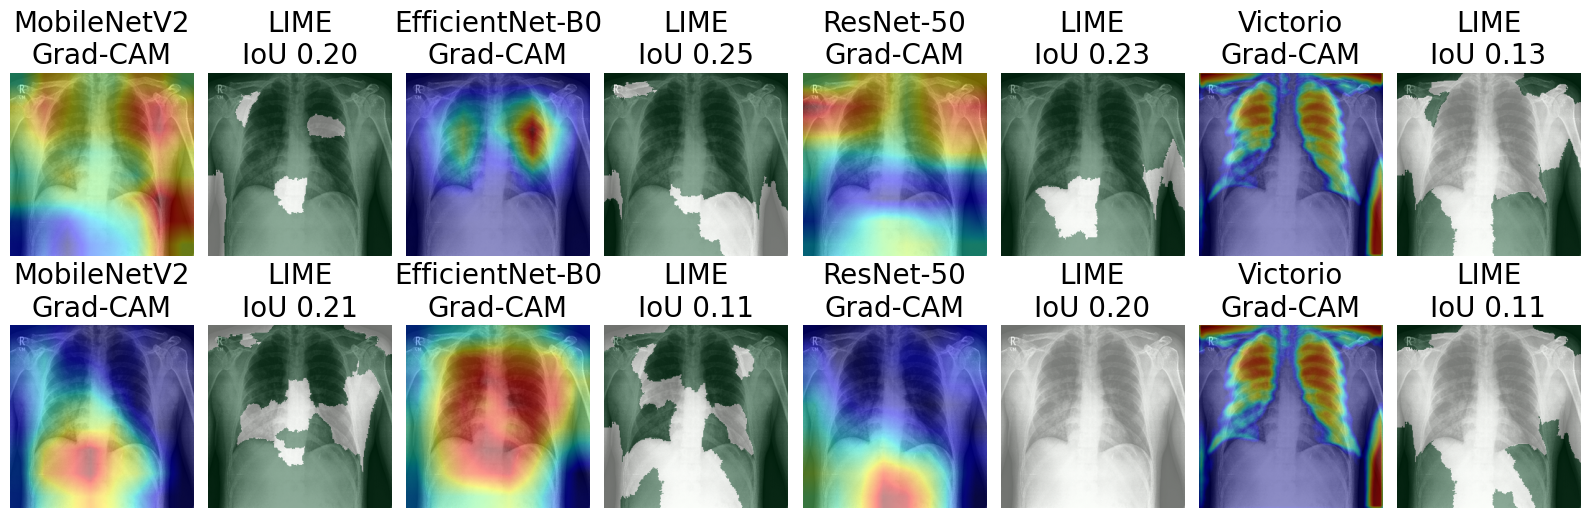

Saved: reports/figures/explainability/attributions_pneumonia.png


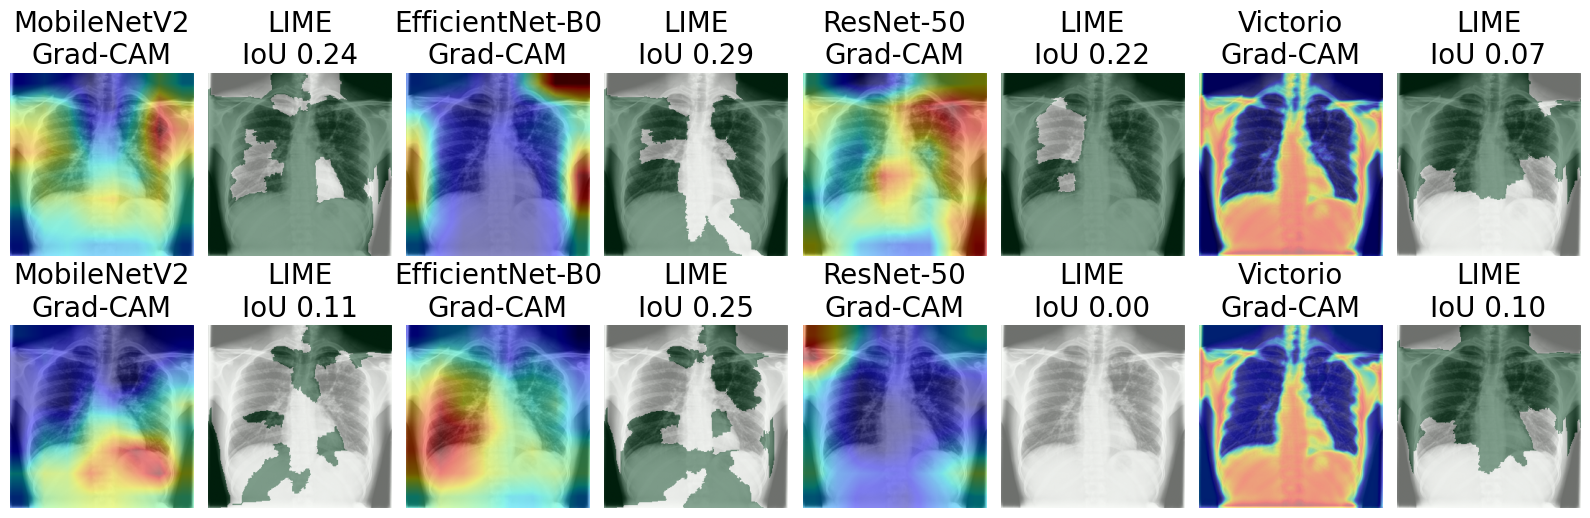

Saved: reports/figures/explainability/attributions_tb.png


In [17]:
representative = (sample_df.groupby("Class").head(1).reset_index(drop=True))
print("Representative cases:", representative["rel_path"].tolist())
for cls in representative["Class"]:
    row = representative[representative["Class"] == cls].iloc[0]
    true_idx = CLASS_TO_INDEX[cls]
    fig, axes = plt.subplots(2, len(MODEL_NAMES) * 2,
                             figsize=(4 * len(MODEL_NAMES), 5.5))
    for j, regime in enumerate(REGIMES):
        mean, std = ((IMAGENET_MEAN, IMAGENET_STD) if regime == "imagenet"
                     else (CXR_MEAN, CXR_STD))
        _, eval_tf = build_shared_transforms(img_size=IMG_SIZE, mean=mean, std=std)
        mean_t = torch.tensor(mean).view(1, 3, 1, 1).to(DEVICE)
        std_t  = torch.tensor(std).view(1, 3, 1, 1).to(DEVICE)
        for i, arch in enumerate(MODEL_NAMES):
            model, target_layer = load_checkpoint(arch, regime)
            def batch_predict(batch):
                with torch.no_grad():
                    t = torch.from_numpy(np.stack(batch)).permute(0, 3, 1, 2).float().to(DEVICE)
                    return torch.softmax(model((t - mean_t) / std_t), dim=1).cpu().numpy()
            pil = Image.open(row["resolved"]).convert("RGB")
            tensor = eval_tf(pil).unsqueeze(0).to(DEVICE)
            rgb = np.asarray(pil.resize((IMG_SIZE, IMG_SIZE)), dtype=np.float64) / 255.0
            engine = GradCAM(model, target_layer)
            cam = engine.generate(tensor, class_idx=true_idx)
            engine.remove()
            expl = explainer.explain_instance(
                rgb, batch_predict, labels=(true_idx,), top_labels=None,
                hide_color=0, num_samples=LIME_SAMPLES,
                batch_size=LIME_BATCH, random_seed=SEED,
            )
            l_mask = lime_mask(expl, true_idx)
            ax_cam = axes[j, i * 2]
            ax_cam.imshow(rgb)
            ax_cam.imshow(cam, cmap="jet", alpha=0.45)
            ax_cam.set_title(f"{DISPLAY[arch]}\nGrad-CAM", fontsize=20)
            ax_cam.axis("off")
            ax_lime = axes[j, i * 2 + 1]
            ax_lime.imshow(rgb)
            ax_lime.imshow(l_mask, cmap="Greens", alpha=0.45)
            ax_lime.set_title(f"LIME\nIoU {iou(gradcam_mask(cam, PRIMARY_TOPK), l_mask):.2f}",
                              fontsize=20)
            ax_lime.axis("off")
        axes[j, 0].set_ylabel("ImageNet" if regime == "imagenet" else "CXR")
    plt.tight_layout()
    out = FIG_DIR / f"attributions_{cls.lower()}.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out.relative_to(PROJECT_ROOT))

## 11. Sample Radiographs per Class.

Reviewer 4 asked for example images from each class. The archived version of
this figure was drawn from the superseded corpus and may contain images from
`imgs/sick`, which were labelled tuberculosis in error.

#### Rationale:
- Draw from the clean corpus, so the displayed tuberculosis cases are genuine.
- Label the tuberculosis panels with their activity annotation, since the class
  contains both active and healed disease.
- Show several cases per class, so that within-class variation is apparent.
- Export at publication resolution for the appendix.

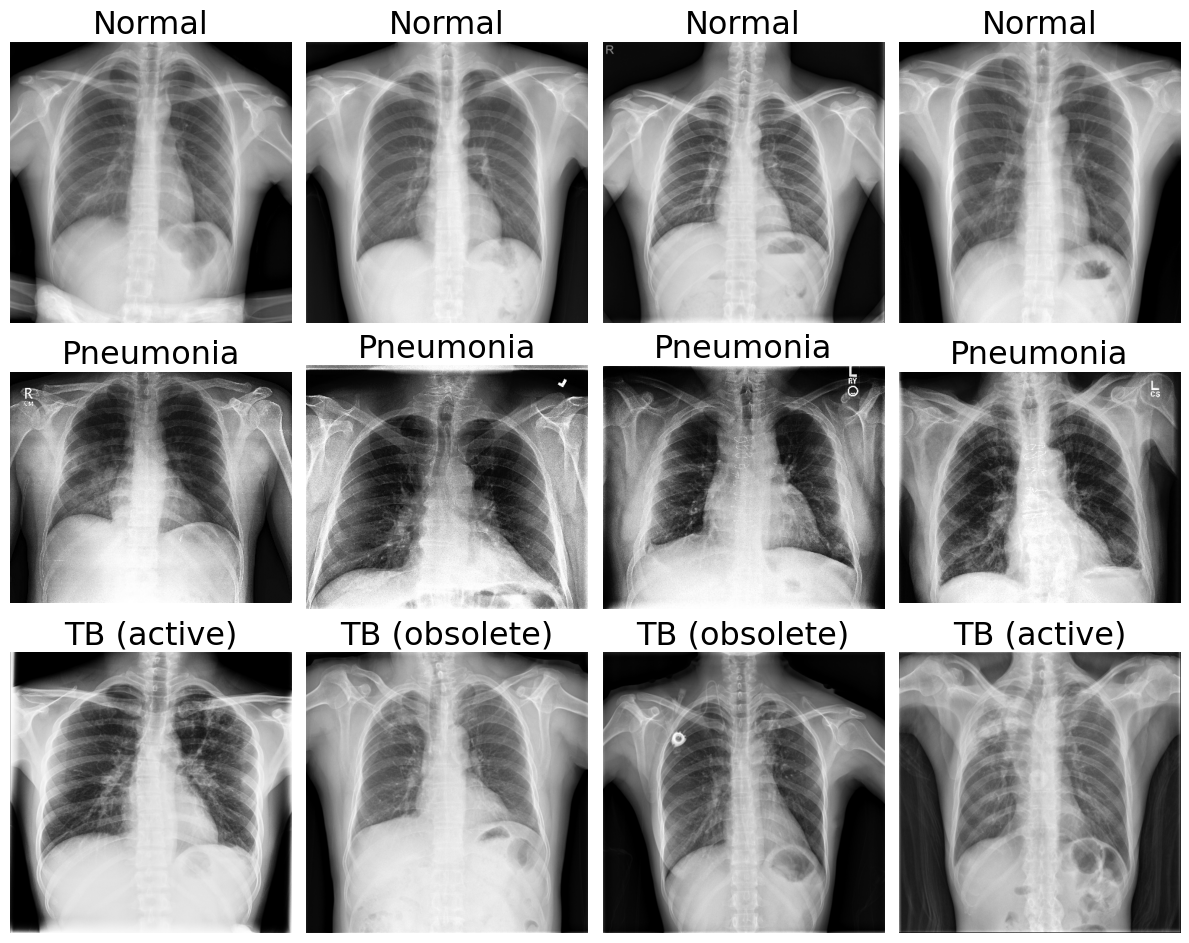

Saved: reports/figures/sample_images_per_class.png


In [15]:
N_SHOW = 4
fig, axes = plt.subplots(3, N_SHOW, figsize=(3 * N_SHOW, 9.5))
for r, cls in enumerate(["Normal", "Pneumonia", "TB"]):
    subset = test_df[test_df["Class"] == cls].sample(n=N_SHOW, random_state=SEED)
    for c, (_, row) in enumerate(subset.iterrows()):
        ax = axes[r, c]
        ax.imshow(Image.open(row["resolved"]).convert("L"), cmap="gray")
        if cls == "TB":
            ax.set_title(f'TB ({row["tb_activity"]})', fontsize=23)
        else:
            ax.set_title(cls, fontsize=23)
        ax.axis("off")
    axes[r, 0].set_ylabel(cls, fontsize=12)

plt.tight_layout()
out = PROJECT_ROOT / "reports" / "figures" / "sample_images_per_class.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", out.relative_to(PROJECT_ROOT))

## Appendix: What Changed and Why.

**The previous measurement.** The index was computed by globbing the rendered
Grad-CAM and LIME PNG files, converting them to greyscale, and thresholding each
at its own seventieth percentile. Two independent faults followed. First, a
rendered LIME figure is mostly black, so more than seventy per cent of its pixels
were exactly zero, the seventieth percentile was zero, and the mask selected
every pixel. Second, a colourmap is not monotonic in luminance, so even a
correctly thresholded rendered heatmap would not recover the ordering of the
underlying activations.

The consequence is arithmetic. Where both figures were mostly black, both masks
were everything and the index was exactly 1.0. Otherwise the Grad-CAM mask held
thirty per cent of pixels inside a LIME mask of one hundred per cent, giving
0.30. With one image per class, each model-regime pair produced the three values
1.0, 0.30, 0.30, whose mean is 0.5333 and whose sample standard deviation is
0.4041. The submitted paper reports 0.534 to 0.537 plus or minus 0.401 to 0.404.

**This measurement.** Both masks come from the underlying data: the Grad-CAM
mask by rank from the activation array, the LIME mask as the union of positive
superpixel weights from the explanation object. Twenty images per class per pair
rather than one. Three thresholds rather than one, with the rank correlation
between them reported so that threshold dependence is measured.

**What to write.** If the ordering is preserved across thresholds, report the
index at the primary threshold with the sensitivity table as support. If it is
not, the index is threshold-dominated and Section 5.2 should be replaced with a
qualitative treatment. The decision follows from Section 8 and should not be
taken in advance.

**A caveat that applies either way.** The Grad-CAM mask has fixed area by
construction while the LIME mask does not, so the attainable maximum is the
ratio of the two areas rather than one. Mask coverage is reported alongside the
index for that reason, and any absolute value should be read against it.